# Whitespot analysis

The purpose of this final notebook is to use a previously obtained model to find locations with the highest sales potential for our client.

In [58]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
import joblib

PROCESSED_PATH = Path("../data/processed")

features_df      = pd.read_csv(PROCESSED_PATH / "features.csv")
gdf_locations    = gpd.read_parquet(PROCESSED_PATH / "gdf_locations.parquet")
gdf_competitors  = gpd.read_parquet(PROCESSED_PATH / "gdf_competitors.parquet")
gdf_poi          = gpd.read_parquet(PROCESSED_PATH / "gdf_poi.parquet")
gdf_area         = gpd.read_parquet(PROCESSED_PATH / "gdf_area.parquet")
gdf_districts    = gpd.read_parquet(PROCESSED_PATH / "gdf_districts.parquet")
gdf_buildings    = gpd.read_parquet(PROCESSED_PATH / "gdf_buildings.parquet")
gdf_population   = gpd.read_parquet(PROCESSED_PATH / "gdf_population.parquet")

with open(PROCESSED_PATH / 'analysis_bbox.json') as f:
    ANALYSIS_BBOX = json.load(f)

model = joblib.load(PROCESSED_PATH / 'model.joblib')

### Grid generation

H3 hexagonal grid (Uber H3) is used to generate candidate locations
across the analysis area. Compared to a regular lat/lng grid, hexagons
minimise directional bias — each cell has 6 equidistant neighbours,
avoiding the corner-distance problem of square grids. Each H3 cell
centroid serves as a candidate location for a potential new store,
with features computed within a 1500m radius from that centroid.

In [2]:
import h3
from shapely.geometry import Point

def split_to_cells(resolution, area):
    analysis_geojson = area.geometry.iloc[0].__geo_interface__

    h3_cells = h3.geo_to_cells(analysis_geojson, resolution)
    print(f"H3 cells at resolution {resolution}: {len(h3_cells)}")

    grid_points = []
    for cell in h3_cells:
        lat, lng = h3.cell_to_latlng(cell)
        grid_points.append({
            'location_id': cell,
            'lat': lat,
            'lng': lng,
            'geometry': Point(lng, lat),
            'h3_cell': cell
        })

    grid_gdf = gpd.GeoDataFrame(grid_points, crs='EPSG:4326')
    print(f"Grid: {len(grid_gdf)} candidate locations")
    return grid_gdf

In [3]:
grid_6 = split_to_cells(6, gdf_area)

H3 cells at resolution 6: 162
Grid: 162 candidate locations


In [4]:
grid_7 = split_to_cells(7, gdf_area)

H3 cells at resolution 7: 1128
Grid: 1128 candidate locations


We will resort to resolution equal to 6 — resolution 7 yields 1,128 cells which would make footfall computation prohibitively slow (~5 hours via Snowflake batch queries). Resolution 6 grids have a diameter of 1200m. Our features use a 1500-meter radius, so they span over a full grid away from a proposed centroid. Our recommendations will be based on the centroid - ground-level verification is required to determine where exactly in the hexagon a store should be built.

In [5]:
from src.features import (
    compute_competitor_features,
    compute_poi_features,
    compute_buildings_features,
    compute_population_features,
    compute_footfall_features
)

BBOX_FILTER = f"""
    CAST(latitude AS FLOAT) BETWEEN {ANALYSIS_BBOX['lat_min']} AND {ANALYSIS_BBOX['lat_max']}
    AND CAST(longitude AS FLOAT) BETWEEN {ANALYSIS_BBOX['lng_min']} AND {ANALYSIS_BBOX['lng_max']}
"""

DATE_FILTER = """
    YEAR(TRY_TO_TIMESTAMP(occured_at)) = 2020
    AND MONTH(TRY_TO_TIMESTAMP(occured_at)) = 7
"""

BASE_FILTER = f"""
    {BBOX_FILTER} AND {DATE_FILTER}
"""

RADIUS = 1500

Let's compute our features for the all new potential locations.

In [6]:
competitor_df = compute_competitor_features(grid_6, gdf_competitors, RADIUS)
poi_df = compute_poi_features(grid_6, gdf_poi, RADIUS)
building_df = compute_buildings_features(grid_6, gdf_buildings, RADIUS)
population_df = compute_population_features(grid_6, gdf_population, RADIUS)
footfall_df = compute_footfall_features(grid_6, BASE_FILTER, RADIUS)

Batch 1 done
Batch 2 done
Batch 3 done
Batch 4 done
Batch 5 done
Batch 6 done


In [89]:
grid_features = (
    grid_6[['location_id', 'lat', 'lng']]
    .merge(competitor_df, on='location_id', how='left')
    .merge(poi_df, on='location_id', how='left')
    .merge(building_df, on='location_id', how='left')
    .merge(population_df, on='location_id', how='left')
    .merge(footfall_df, on='location_id', how='left')
)

grid_features.to_csv(PROCESSED_PATH / "grid_features.csv")

print(f"Shape: {grid_features.shape}")
print(grid_features.isnull().sum())

Shape: (162, 28)
location_id                   0
lat                           0
lng                           0
competitor_count_1500m        0
nearest_competitor_m          0
poi_count_1500m               0
nearest_poi_m                 0
poi_restaurant_count_1500m    0
nearest_poi_restaurant_m      0
poi_bank_count_1500m          0
nearest_poi_bank_m            0
poi_school_count_1500m        0
nearest_poi_school_m          0
poi_bus_stop_count_1500m      0
nearest_poi_bus_stop_m        0
poi_park_count_1500m          0
nearest_poi_park_m            0
poi_pharmacy_count_1500m      0
nearest_poi_pharmacy_m        0
poi_hospital_count_1500m      0
nearest_poi_hospital_m        0
poi_mall_count_1500m          0
nearest_poi_mall_m            0
building_count_1500m          0
residential_ratio_1500m       0
population_1500m              0
signals_1500m                 0
unique_users_1500m            0
dtype: int64


The purpose of whitespot analysis is to find the areas where market is not yet satisfied by the client or competition. Therefore, we will filter for locations that are more than 3000 m from the nearest client store and in the 1500-meter radius of which there are no competitors.

In [84]:
MIN_DIST_OWN_STORE = 3000
MAX_COMPETITORS = 0

grid_gdf = gpd.GeoDataFrame(
    grid_features,
    geometry=gpd.points_from_xy(grid_features.lng, grid_features.lat),
    crs='EPSG:4326'
).to_crs('EPSG:2180')

locs_proj = gdf_locations.to_crs('EPSG:2180')

grid_gdf['dist_to_own_store'] = grid_gdf['geometry'].apply(
    lambda p: locs_proj.geometry.distance(p).min()
)

grid_filtered = grid_gdf[
    (grid_gdf['dist_to_own_store'] >= MIN_DIST_OWN_STORE) &
    (grid_gdf['competitor_count_1500m'] == MAX_COMPETITORS)
].copy()

print(f"Before filter: {len(grid_features)} locations")
print(f"After own store filter: {len(grid_gdf[grid_gdf['dist_to_own_store'] >= MIN_DIST_OWN_STORE])} locations")
print(f"After both filters: {len(grid_filtered)} locations")

Before filter: 162 locations
After own store filter: 137 locations
After both filters: 131 locations


We are left with 131 out of 162 locations — 25 were removed due to proximity to existing client stores, and 6 due to competitor presence.

Let's calculate predicted revenue for each new location. We will calculate the score of each filtered prediction by normalizing the revenue predicted by the model for our filtered locations. A value of 100 will mean that the location exhibits the highest monthly revenue predicted by the model in our analysis area for a filtered set of 131 locations. Conversely, the value of 0 will mean that the model predicted the lowest revenue value for this location.

In [67]:
X_grid = grid_filtered[model.feature_names_in_]
grid_filtered['predicted_revenue'] = model.predict(X_grid)
min_r = grid_filtered['predicted_revenue'].min()
max_r = grid_filtered['predicted_revenue'].max()
grid_filtered['score'] = ((grid_filtered['predicted_revenue'] - min_r) / (max_r - min_r) * 100).round(1)

Let's analyze the distribution of predicted revenues and score, and display the top 10 locations

In [68]:
print(grid_filtered[['location_id', 'predicted_revenue', 'score']].describe())
print(f"\nTop 10 locations:")
top10 = grid_filtered.nlargest(10, 'score')[['location_id', 'lat', 'lng', 'predicted_revenue', 'score']]
top10

       predicted_revenue       score
count         131.000000  131.000000
mean       210802.828125   29.635117
std         34678.937500   21.021242
min        161911.281250    0.000000
25%        187928.125000   15.750000
50%        200766.687500   23.600000
75%        228855.781250   40.600000
max        326898.500000  100.000000

Top 10 locations:


,location_id,lat,lng,predicted_revenue,score
61,861e2e5a7ffffff,50.345291,19.256846,326898.50000,100.000000
127,861e23217ffffff,50.375970,18.838482,302534.46875,85.199997
93,861e23657ffffff,50.121531,18.594131,299758.43750,83.599998
117,861e2e09fffffff,50.368104,19.902976,299008.34375,83.099998
24,861e0592fffffff,50.198769,18.976890,297425.09375,82.099998
136,861e2e597ffffff,50.255203,19.203664,294636.31250,80.400002
90,861e232a7ffffff,50.339200,18.768603,292362.25000,79.099998
69,861e2e097ffffff,50.385541,19.815974,281970.93750,72.800003
19,861e0596fffffff,50.201615,19.220564,277247.37500,69.900002
99,861e232cfffffff,50.272145,19.116711,277192.50000,69.900002


It's important to consider the predicted revenue, not just scores. Our top location is predicted to achieve a monthly revenue of 326k - more than the third quantile of existing stores monthly revenue, but less than the best-earning store.

Let's construct a layered map with a whitespot score for each grid and top 10 locations clearly labeled.

In [90]:
import folium
from folium.plugins import HeatMap

centroid = gdf_area.geometry.iloc[0].centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=10)

folium.GeoJson(
    gdf_area,
    name='Analysis area',
    style_function=lambda x: {'color': 'black', 'weight': 2, 'fillOpacity': 0.02}
).add_to(m)

heat_data = [[row['lat'], row['lng'], row['score']]
             for _, row in grid_filtered.iterrows()]
HeatMap(heat_data, name='Whitespot score',
        min_opacity=0.3, radius=30, blur=20).add_to(m)

top10_group = folium.FeatureGroup(name='Top 10 candidate locations')
for _, row in top10.iterrows():
    folium.Marker(
        location=[row['lat'], row['lng']],
        popup=folium.Popup(
            f"<b>Score: {row['score']:.1f}/100</b><br>"
            f"Est. revenue: {row['predicted_revenue']:,.0f} PLN<br>"
            f"H3: {row['location_id']}",
            max_width=200
        ),
        icon=folium.Icon(color='red', icon='star')
    ).add_to(top10_group)
top10_group.add_to(m)

clients_group = folium.FeatureGroup(name='Existing client stores')
for _, row in gdf_locations.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=6,
        color='blue',
        fill=True,
        fillColor='blue',
        fillOpacity=0.7,
        popup=f"{row['location_id']}: {row['monthly_revenue']:,.0f} PLN"
    ).add_to(clients_group)
clients_group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save('../data/outputs/whitespot_map.html')
m

We plotted heatmap results and displayed top 10 and worst 10 locations. There are spots on the map that are missing a heatmap - that means those locations did not pas through our filter, i.e. there is already a client's location in the 3000-meter radius from there or there is a competitor in a 1500-meter radius.

Let's take a closer look at top 10 predicted locations and their features. We will focus on 5 features that were the most important based on feature
importance analysis in the previous notebook. We will also include `residential_ratio_1500m` — as neighborhood character is a factor a client would naturally consider when choosing a location — and both competitor features, as competition density is a key business consideration for expansion decisions regardless of model weighting and are something a client would definitely want to know about.

In [74]:
ANALYSIS_FEATURES = [
    'nearest_poi_pharmacy_m',
    'unique_users_1500m',
    'population_1500m',
    'nearest_poi_park_m',
    'poi_bus_stop_count_1500m',
    'residential_ratio_1500m',
    'competitor_count_1500m',
    'nearest_competitor_m',
]

Before analysis of individual locations, let's inspect the distribution of features across grids:

In [75]:
grid_filtered[ANALYSIS_FEATURES].describe()

,nearest_poi_pharmacy_m,unique_users_1500m,population_1500m,nearest_poi_park_m,poi_bus_stop_count_1500m,residential_ratio_1500m,competitor_count_1500m,nearest_competitor_m
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.0,131.000000
mean,8823.910816,138.977099,2312.450382,8426.448046,0.053435,0.535255,0.0,6967.168025
std,5053.846626,210.696262,4037.101207,4007.368469,0.257592,0.146223,0.0,4205.044738
min,365.326870,0.000000,0.000000,1596.694556,0.000000,0.000000,0.0,1538.662084
25%,4719.338263,18.000000,425.500000,5113.483497,0.000000,0.468040,0.0,3640.036923
50%,8554.648330,63.000000,1110.000000,8137.618643,0.000000,0.553667,0.0,5936.586985
75%,12233.260619,171.500000,2405.500000,11391.265645,0.000000,0.624198,0.0,8891.994144
max,23662.998180,1422.000000,31037.000000,18197.906406,2.000000,0.796154,0.0,20868.230444


In [76]:
top10_features = grid_filtered[grid_filtered['location_id'].isin(top10['location_id'])].sort_values('score', ascending=False)
top10_features[ANALYSIS_FEATURES]

,nearest_poi_pharmacy_m,unique_users_1500m,population_1500m,nearest_poi_park_m,poi_bus_stop_count_1500m,residential_ratio_1500m,competitor_count_1500m,nearest_competitor_m
61,2367.126900,426.0,2037,3827.065925,0,0.345926,0,4098.078836
127,1216.183577,389.0,12186,3161.976406,0,0.644898,0,3002.224537
93,2448.163640,80.0,671,3619.814900,0,0.542208,0,3542.367947
117,2251.152590,48.0,504,3603.177273,0,0.345423,0,20868.230444
24,1207.427559,871.0,22040,1871.085651,0,0.710531,0,5278.154364
136,4593.737810,333.0,732,4191.942383,0,0.407787,0,3561.990021
90,3404.790140,563.0,14681,3590.109030,1,0.694813,0,3496.685258
69,4233.773611,47.0,802,4036.540898,0,0.441691,0,18701.350369
19,10583.512552,53.0,1,3308.111315,0,0.003484,0,8136.805539
99,3648.520688,1422.0,31037,2144.618426,0,0.421110,0,2359.459469


Let's talk about top 3 locations:

**#1 — Dąbrowa Górnicza, Gołonóg (score: 100/100)**

The model's top pick sits in Gołonóg, directly adjacent to Huta Katowice — one of the largest steel plants in Poland. Despite the industrial surroundings, the location shows strong foot traffic: 426 unique users within 1,500m places it well above the 75th percentile of the filtered grid (171.5). Population of 2,037 is above the grid median (1,110). Pharmacy at 2,367m and park at 3,827m are both well below the grid medians (8,554m and 8,137m respectively), indicating proximity to services relative to other candidates. Zero competitors within 1,500m (nearest at 4,098m) confirms an uncontested market. Residential ratio of 35% is below the grid median (0.55), reflecting the industrial character of the surroundings.

The H3 cell centroid falls near the industrial boundary — in practice, a new store would be sited in the adjacent residential area of Gołonóg rather than on the plant premises. The low residential ratio warrants ground-level verification of actual residential density in the vicinity.

**#2 — Bytom, Miechowice (score: 85.2/100)**

The second candidate sits in Miechowice, a residential district of Bytom
near Góra Drzezgowiec. With a population of 12,186 within 1,500m — well
above the 75th percentile of the analysis grid (2,405) — and a residential
ratio of 65%, this is a well-populated neighbourhood with a clear residential
character. Foot traffic is high (389 unique users). Zero competitors
within 1,500m, with the nearest at 3,002m, confirms an underserved market.

The model rewards its distance-based POI profile — 1,216m to the nearest
pharmacy and 3,162m to the nearest park place it in the urban periphery
of the Bytom agglomeration. Ground-level verification is recommended to
confirm residential density and accessibility.

The H3 cell centroid falls in the forest — in practice,
a new store would be sited in the adjacent residential area of Miechowice.

**#3 — Rybnik Kamień recreational area, Leszczyny/Czerwionka border
(score: 83.6/100)**

The third candidate sits near Park Rekreacyjno-Wypoczynkowy Rybniki Kamień,
between Leszczyny and Czerwionka-Leszczyny. The location shows a modest
residential footprint — population of 671 within 1,500m is below the grid
median, and unique users (80) are low. The model ranks it highly due to
its POI distance profile: 2,448m to the nearest pharmacy and 3,620m to
the nearest park, with zero competitors in the area (nearest at 3,542m).

Similarly to #1, the low population and foot traffic figures warrant
ground-level verification — the model may be rewarding peripheral
characteristics rather than genuine commercial potential.

Let's inspect those three candidates closer using SHAP analysis to explain the exact model decisions.

In [85]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

def explain_location(model, X_background, X_row, location_name):
    """
    Generate SHAP waterfall plot for a single location.

    model: trained XGBRegressor
    X_background: full training data (X) — used as reference for SHAP
    X_row: single-row DataFrame with features for this location
    location_id: string label for the plot title
    """
    explainer = shap.TreeExplainer(model, X_background.values)
    shap_values = explainer.shap_values(X_row.values)

    explanation = shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_row.iloc[0].to_numpy(),
        feature_names=list(X_row.columns)
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"SHAP explanation — {location_name}")
    plt.tight_layout()
    plt.savefig(f'../data/outputs/shap_{location_name.replace(" ", "_").replace(",", "").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    shap_series = pd.Series(
        shap_values[0],
        index=X_row.columns
    ).sort_values(key=lambda s: s.abs(), ascending=False)

    return shap_series

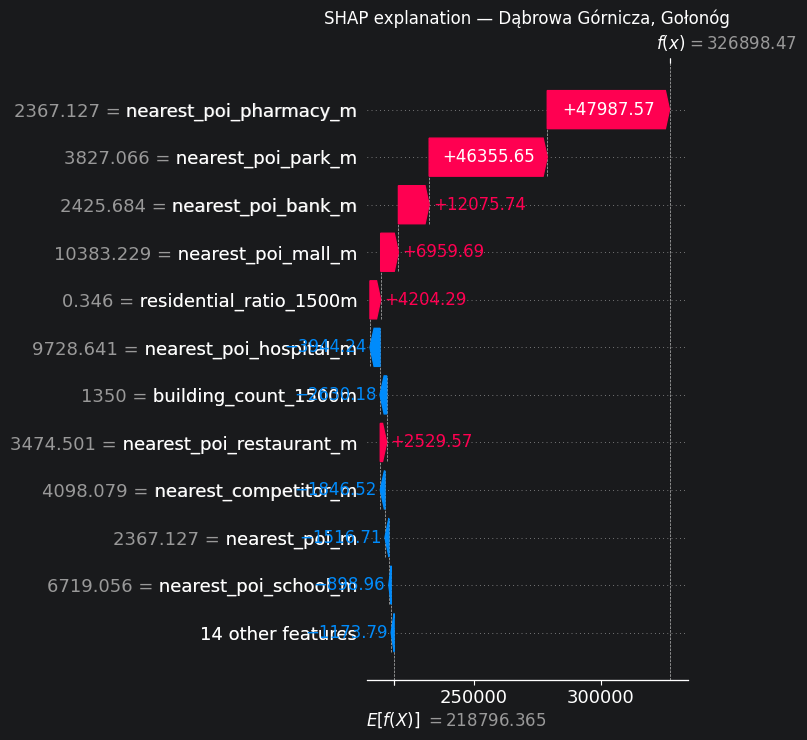


Dąbrowa Górnicza, Gołonóg — top 5 SHAP features:
nearest_poi_pharmacy_m     47987.566914
nearest_poi_park_m         46355.649722
nearest_poi_bank_m         12075.736732
nearest_poi_mall_m          6959.689464
residential_ratio_1500m     4204.289252
dtype: float64


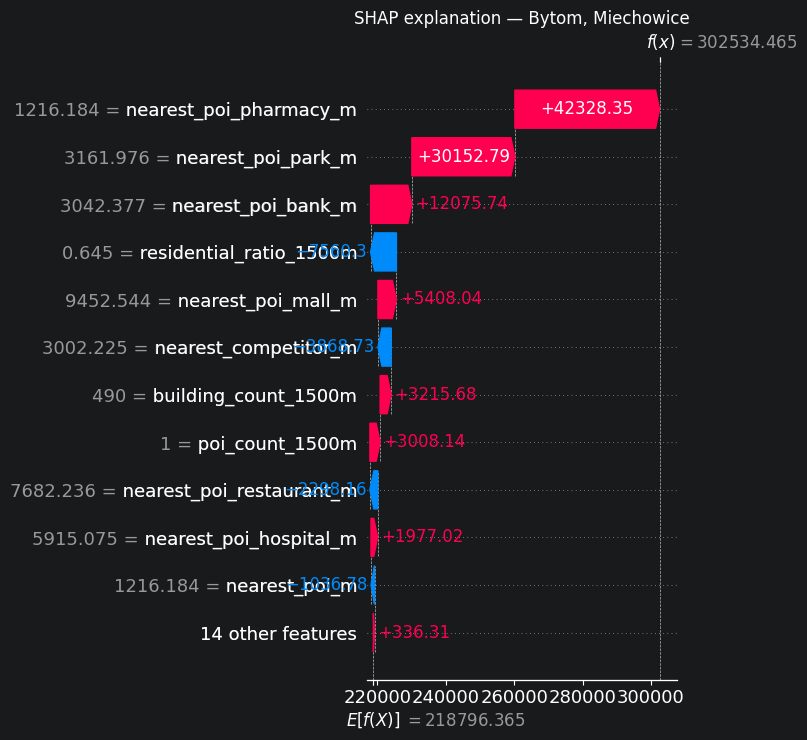


Bytom, Miechowice — top 5 SHAP features:
nearest_poi_pharmacy_m     42328.348140
nearest_poi_park_m         30152.789717
nearest_poi_bank_m         12075.736732
residential_ratio_1500m    -7560.298207
nearest_poi_mall_m          5408.041495
dtype: float64


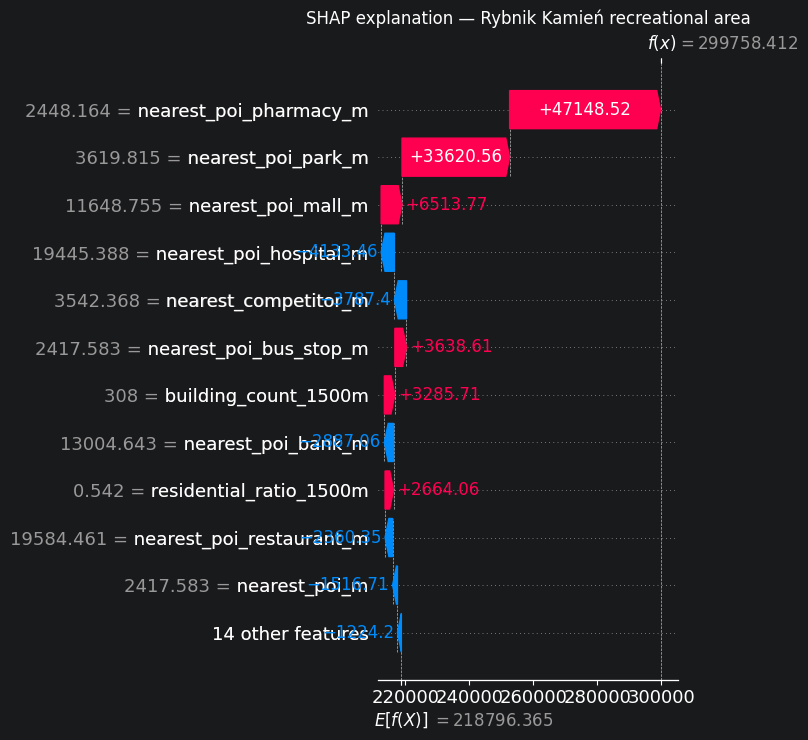


Rybnik Kamień recreational area — top 5 SHAP features:
nearest_poi_pharmacy_m    47148.518760
nearest_poi_park_m        33620.563652
nearest_poi_mall_m         6513.768801
nearest_poi_hospital_m    -4133.460306
nearest_competitor_m      -3787.399370
dtype: float64


In [86]:
top3_ids = {
    '861e2e5a7ffffff': 'Dąbrowa Górnicza, Gołonóg',
    '861e23217ffffff': 'Bytom, Miechowice',
    '861e23657ffffff': 'Rybnik Kamień recreational area',
}

for loc_id, loc_name in top3_ids.items():
    X_row = grid_features[
        grid_features['location_id'] == loc_id
    ][model.feature_names_in_]

    shap_series = explain_location(model, X_grid, X_row, loc_name)
    print(f"\n{loc_name} — top 5 SHAP features:")
    print(shap_series.head(5))

SHAP waterfall plots decompose each location's predicted revenue into
per-feature contributions relative to the training set mean
(E[f(X)] = ~219k PLN).

`nearest_poi_pharmacy_m` and `nearest_poi_park_m` are the dominant
positive drivers across all three locations — contributing +42k to +48k
and +30k to +46k PLN respectively. Together they account for the majority
of each location's predicted revenue above the mean.

This pattern is consistent across all three locations regardless of their
very different fundamental characteristics — Dąbrowa (industrial, low
population), Bytom (residential, moderate population) and Rybnik Kamień
(rural, very low population) all receive similar large positive
contributions from the same two features. This consistency indicates that
these two features dominate the model's predictions across very different
location types — regardless of population, foot traffic or competitive environment.

The relationship between POI distances and predicted revenue is non-linear
and context-dependent — SHAP values for `nearest_poi_pharmacy_m` range
from +42k (Bytom, 1,216m) to +48k (Dąbrowa, 2,367m) to +47k (Rybnik
Kamień, 2,448m), with no simple "closer = better" or "further = better" rule. The model learned
conditional patterns from the training data that cannot be reduced to a
single directional relationship.

Both features show negative Pearson correlation with revenue in the
training data (nearest_poi_pharmacy_m: r=−0.507, nearest_poi_park_m:
r=−0.391) — meaning stores closer to pharmacies and parks generally
earn more. The SHAP contributions here are all positive despite these
locations being relatively far from both POI types, which reflects the
non-linear, conditional nature of tree-based models: the model rewards
these distances in the context of this specific feature combination,
even when the global correlation points in the opposite direction.

Notably, `residential_ratio_1500m` penalises Bytom (−7.6k PLN) despite
its 65% residential character — a counter-intuitive result that likely
reflects a specific pattern learned from a small number of training
observations rather than a general business rule.

Ground-level assessment is strongly recommended before acting on model
output alone. Bytom (Miechowice) stands out as the most balanced candidate
among the three — combining reasonable population, residential character
and zero competition, without the low-demand concerns of Rybnik Kamień
or the industrial character of Dąbrowa.

Finally, to finish our analysis, let's compare the mean across our ANALYSIS FEATURES for our top 3 predicted locations and top 3 existing locations (according to revenue). Note that averaging three locations with very different profiles may obscure meaningful differences — the comparison should be read as directional rather than precise.

In [82]:
top3_existing = features_df.nlargest(3, 'monthly_revenue')

top3_candidates = grid_filtered[
    grid_filtered['location_id'].isin(top3_ids.keys())
]

comparison = pd.DataFrame({
    'Top 3 existing (by revenue)': top3_existing[ANALYSIS_FEATURES].mean(),
    'Top 3 candidates': top3_candidates[ANALYSIS_FEATURES].mean()
}).round(2)

comparison

,Top 3 existing (by revenue),Top 3 candidates
nearest_poi_pharmacy_m,1530.68,2010.49
unique_users_1500m,2278.00,298.33
population_1500m,31329.67,4964.67
nearest_poi_park_m,4044.65,3536.29
poi_bus_stop_count_1500m,0.00,0.00
residential_ratio_1500m,0.49,0.51
competitor_count_1500m,1.00,0.00
nearest_competitor_m,1647.12,3547.56


Comparing the recommended locations against the three highest-earning
existing stores reveals a striking contrast in their spatial profiles.

The top-earning existing stores are characterized by very high foot
traffic (2,278 unique users on average) and large population catchment
(31,330 residents) — both far exceeding the candidate locations
(298 unique users, 4,965 residents). This confirms the model's known
limitation: foot traffic and population are genuine drivers of revenue
in the existing store data, but the model does not weight them strongly
enough in scoring new locations. Interestingly, there is no significant difference
in residential ratio between those two groups, despite existing locations having a 6 times
higher total population.

The candidates, however, outperform on competitive positioning — zero
competitors on average vs one for the top existing stores, with the
nearest competitor 3,548m away vs 1,647m. This is the direct result
of the applied filters (MIN_DIST_OWN_STORE = 3,000m, MAX_COMPETITORS = 0)
and reflects the core whitespot premise: identifying underserved areas
rather than replicating existing high-traffic locations.

The practical implication is that the recommended locations represent
a different expansion hypothesis — lower initial foot traffic but
uncontested market, in contrast to the existing stores which operate
in high-demand but more competitive environments.